DATASET CREATED
Total samples: 120

Emotion distribution:
sentiment
happy       15
sad         15
angry       15
fear        15
love        15
surprise    15
disgust     15
neutral     15
Name: count, dtype: int64

DATA SPLIT
Training samples: 96
Testing samples: 24

TF-IDF CREATED
Number of TF-IDF features: 456

TRAINING MODEL
Model training completed!

MODEL ACCURACY
Accuracy: 41.67 %

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.25      0.33      0.29         3
     disgust       0.50      0.33      0.40         3
        fear       1.00      1.00      1.00         3
       happy       0.20      0.33      0.25         3
        love       0.40      0.67      0.50         3
     neutral       0.50      0.33      0.40         3
         sad       0.00      0.00      0.00         3
    surprise       1.00      0.33      0.50         3

    accuracy                           0.42        24
   macro avg       0.48      0.42      0.42  

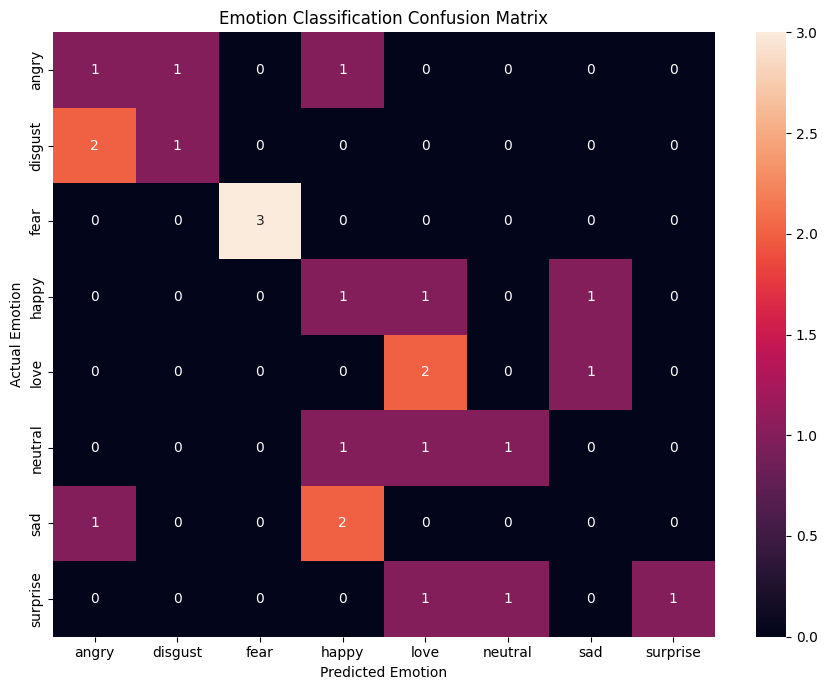


TF-IDF SAVED
tfidf_vectorizer.pkl created successfully!

MODEL SAVED
emotion_model.pkl created successfully!

TESTING PICKLED FILES
Both pickle files loaded successfully!

TEST RESULT
Input: I got selected for my dream job
Predicted Emotion: LOVE
Confidence: 17.99 %

EMOTION DETECTION



Enter a sentence:  I got my dream job



RESULT
Input: I got my dream job
Predicted Emotion: HAPPY
Confidence: 18.2 %

EMOTION PROBABILITIES
HAPPY      : 18.20%
LOVE       : 16.99%
SAD        : 12.95%
ANGRY      : 10.85%
SURPRISE   : 10.38%
NEUTRAL    : 10.36%
DISGUST    : 10.15%
FEAR       : 10.11%

PROJECT COMPLETE

Copy these two files to your PyCharm project:
1. emotion_model.pkl
2. tfidf_vectorizer.pkl


In [3]:
# ============================================================
# NLP EMOTION CLASSIFICATION
# TF-IDF + LOGISTIC REGRESSION
# PYCHARM COMPATIBLE PICKLE VERSION
# ============================================================

# If required:
# !pip install pandas numpy scikit-learn matplotlib seaborn


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import string
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 2. CREATE DATASET
# ============================================================

data = {

    "text": [

        # ---------------- HAPPY ----------------

        "I am extremely happy today",
        "I feel wonderful",
        "Today was an amazing day",
        "I am so excited about my new job",
        "I got good news today",
        "I am feeling great",
        "This is the best day of my life",
        "I am very pleased with the results",
        "I feel fantastic",
        "I am smiling all day",
        "I achieved my goal today",
        "I am very happy with my results",
        "Everything is going perfectly",
        "I feel so joyful today",
        "I am celebrating my success",

        # ---------------- SAD ----------------

        "I am feeling very sad",
        "Today was a terrible day",
        "I feel lonely",
        "I am crying because I lost my friend",
        "I am disappointed with everything",
        "I feel heartbroken",
        "Nothing seems to make me happy",
        "I miss my family",
        "I feel depressed and alone",
        "I am extremely unhappy",
        "I lost someone important to me",
        "I feel terrible today",
        "Everything feels meaningless",
        "I cannot stop crying",
        "I feel emotionally exhausted",

        # ---------------- ANGRY ----------------

        "I am extremely angry",
        "This makes me furious",
        "I hate this situation",
        "I am so annoyed right now",
        "This is completely unacceptable",
        "I am frustrated with everything",
        "He made me very angry",
        "I cannot control my anger",
        "This is making me furious",
        "I am irritated by this",
        "I am angry about what happened",
        "This situation makes me mad",
        "I am tired of this nonsense",
        "They made me extremely angry",
        "I cannot tolerate this anymore",

        # ---------------- FEAR ----------------

        "I am scared",
        "I am very afraid",
        "I feel terrified",
        "I am worried about what will happen",
        "This situation makes me nervous",
        "I am frightened",
        "I am afraid of losing everything",
        "I feel unsafe",
        "I am extremely nervous",
        "I am scared about the future",
        "I think something bad will happen",
        "I am worried about my exam",
        "I am afraid to go outside",
        "I feel anxious about tomorrow",
        "This situation is frightening",

        # ---------------- LOVE ----------------

        "I love you so much",
        "I really love my family",
        "She is the love of my life",
        "I feel loved",
        "I care deeply about you",
        "I am in love",
        "You mean everything to me",
        "I have strong feelings for her",
        "I love spending time with my friends",
        "My heart is full of love",
        "I love my parents",
        "I really care about him",
        "She makes me feel loved",
        "I adore my family",
        "I have so much love in my heart",

        # ---------------- SURPRISE ----------------

        "Wow I cannot believe this happened",
        "I am completely surprised",
        "I did not expect this at all",
        "This was totally unexpected",
        "I am shocked by the news",
        "I cannot believe what I just saw",
        "What an unbelievable surprise",
        "I never expected this",
        "This surprised me so much",
        "I am shocked",
        "This is completely unexpected",
        "I never thought this would happen",
        "I cannot believe the result",
        "This news shocked me",
        "I was not prepared for this",

        # ---------------- DISGUST ----------------

        "This food tastes disgusting",
        "I feel disgusted",
        "That smell is horrible",
        "This is absolutely disgusting",
        "I cannot stand this smell",
        "That was disgusting",
        "I hate the taste of this",
        "This makes me feel sick",
        "The food looks disgusting",
        "That is really gross",
        "I am disgusted by this",
        "This smells terrible",
        "I cannot tolerate this disgusting food",
        "That was a horrible experience",
        "This is extremely unpleasant",

        # ---------------- NEUTRAL ----------------

        "The meeting is at five pm",
        "I went to the office today",
        "The weather is normal today",
        "I have an exam tomorrow",
        "The train arrives at six",
        "I bought a new notebook",
        "The class starts at ten",
        "I am going to the market",
        "The project is due next week",
        "I finished my homework",
        "The computer is on the table",
        "I went to college today",
        "The store opens at nine",
        "I have a meeting tomorrow",
        "The bus arrived on time"
    ],


    "sentiment": [

        # HAPPY
        "happy","happy","happy","happy","happy",
        "happy","happy","happy","happy","happy",
        "happy","happy","happy","happy","happy",

        # SAD
        "sad","sad","sad","sad","sad",
        "sad","sad","sad","sad","sad",
        "sad","sad","sad","sad","sad",

        # ANGRY
        "angry","angry","angry","angry","angry",
        "angry","angry","angry","angry","angry",
        "angry","angry","angry","angry","angry",

        # FEAR
        "fear","fear","fear","fear","fear",
        "fear","fear","fear","fear","fear",
        "fear","fear","fear","fear","fear",

        # LOVE
        "love","love","love","love","love",
        "love","love","love","love","love",
        "love","love","love","love","love",

        # SURPRISE
        "surprise","surprise","surprise","surprise","surprise",
        "surprise","surprise","surprise","surprise","surprise",
        "surprise","surprise","surprise","surprise","surprise",

        # DISGUST
        "disgust","disgust","disgust","disgust","disgust",
        "disgust","disgust","disgust","disgust","disgust",
        "disgust","disgust","disgust","disgust","disgust",

        # NEUTRAL
        "neutral","neutral","neutral","neutral","neutral",
        "neutral","neutral","neutral","neutral","neutral",
        "neutral","neutral","neutral","neutral","neutral"
    ]
}


# ============================================================
# 3. CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(data)

print("==========================================")
print("DATASET CREATED")
print("==========================================")

print("Total samples:", len(df))

print("\nEmotion distribution:")
print(df["sentiment"].value_counts())


# ============================================================
# 4. TEXT CLEANING FUNCTION
# ============================================================

def clean_text(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


# ============================================================
# 5. CLEAN DATASET
# ============================================================

df["clean_text"] = df["text"].apply(clean_text)


# ============================================================
# 6. X AND Y
# ============================================================

X = df["clean_text"]
y = df["sentiment"]


# ============================================================
# 7. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("\n==========================================")
print("DATA SPLIT")
print("==========================================")

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 8. CREATE TF-IDF VECTORIZER
# ============================================================

vectorizer = TfidfVectorizer(

    ngram_range=(1, 2),

    max_features=5000,

    sublinear_tf=True
)


# ============================================================
# 9. FIT TF-IDF ON TRAINING DATA
# ============================================================

X_train_tfidf = vectorizer.fit_transform(
    X_train
)

X_test_tfidf = vectorizer.transform(
    X_test
)


print("\n==========================================")
print("TF-IDF CREATED")
print("==========================================")

print(
    "Number of TF-IDF features:",
    len(vectorizer.get_feature_names_out())
)


# ============================================================
# 10. CREATE LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(

    max_iter=2000
)


# ============================================================
# 11. TRAIN MODEL
# ============================================================

print("\n==========================================")
print("TRAINING MODEL")
print("==========================================")

model.fit(

    X_train_tfidf,

    y_train
)

print(
    "Model training completed!"
)


# ============================================================
# 12. PREDICTION
# ============================================================

y_pred = model.predict(
    X_test_tfidf
)


# ============================================================
# 13. ACCURACY
# ============================================================

accuracy = accuracy_score(

    y_test,

    y_pred
)


print("\n==========================================")
print("MODEL ACCURACY")
print("==========================================")

print(

    "Accuracy:",

    round(
        accuracy * 100,
        2
    ),

    "%"
)


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\n==========================================")
print("CLASSIFICATION REPORT")
print("==========================================")

print(

    classification_report(

        y_test,

        y_pred
    )
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred,

    labels=model.classes_
)


plt.figure(

    figsize=(9, 7)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=model.classes_,

    yticklabels=model.classes_
)


plt.xlabel(
    "Predicted Emotion"
)

plt.ylabel(
    "Actual Emotion"
)

plt.title(
    "Emotion Classification Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. SAVE TF-IDF VECTORIZER
# ============================================================

with open(

    "tfidf_vectorizer.pkl",

    "wb"

) as file:

    pickle.dump(

        vectorizer,

        file
    )


print("\n==========================================")
print("TF-IDF SAVED")
print("==========================================")

print(
    "tfidf_vectorizer.pkl created successfully!"
)


# ============================================================
# 17. SAVE ML MODEL
# ============================================================

with open(

    "emotion_model.pkl",

    "wb"

) as file:

    pickle.dump(

        model,

        file
    )


print("\n==========================================")
print("MODEL SAVED")
print("==========================================")

print(
    "emotion_model.pkl created successfully!"
)


# ============================================================
# 18. TEST PICKLED FILES
# ============================================================

print("\n==========================================")
print("TESTING PICKLED FILES")
print("==========================================")


# Load vectorizer
with open(

    "tfidf_vectorizer.pkl",

    "rb"

) as file:

    loaded_vectorizer = pickle.load(
        file
    )


# Load model
with open(

    "emotion_model.pkl",

    "rb"

) as file:

    loaded_model = pickle.load(
        file
    )


print(
    "Both pickle files loaded successfully!"
)


# ============================================================
# 19. TEST SENTENCE
# ============================================================

test_sentence = (
    "I got selected for my dream job"
)


# Clean sentence
cleaned_sentence = clean_text(
    test_sentence
)


# TF-IDF transform
sentence_tfidf = loaded_vectorizer.transform(

    [cleaned_sentence]

)


# Prediction
prediction = loaded_model.predict(

    sentence_tfidf

)[0]


# Probability
probabilities = loaded_model.predict_proba(

    sentence_tfidf

)[0]


confidence = max(
    probabilities
) * 100


print("\n==========================================")
print("TEST RESULT")
print("==========================================")


print(
    "Input:",
    test_sentence
)


print(
    "Predicted Emotion:",
    prediction.upper()
)


print(
    "Confidence:",
    round(
        confidence,
        2
    ),
    "%"
)


# ============================================================
# 20. USER INPUT TEST
# ============================================================

print("\n==========================================")
print("EMOTION DETECTION")
print("==========================================")


user_text = input(
    "\nEnter a sentence: "
)


# Clean
cleaned_text = clean_text(
    user_text
)


# TF-IDF
user_tfidf = loaded_vectorizer.transform(

    [cleaned_text]

)


# Prediction
emotion = loaded_model.predict(

    user_tfidf

)[0]


# Probabilities
probabilities = loaded_model.predict_proba(

    user_tfidf

)[0]


confidence = max(
    probabilities
) * 100


print("\n==========================================")
print("RESULT")
print("==========================================")


print(
    "Input:",
    user_text
)


print(
    "Predicted Emotion:",
    emotion.upper()
)


print(
    "Confidence:",
    round(
        confidence,
        2
    ),
    "%"
)


# ============================================================
# 21. ALL EMOTION PROBABILITIES
# ============================================================

print("\n==========================================")
print("EMOTION PROBABILITIES")
print("==========================================")


for emotion_name, probability in sorted(

    zip(
        loaded_model.classes_,
        probabilities
    ),

    key=lambda x: x[1],

    reverse=True

):

    print(

        f"{emotion_name.upper():10s} : "
        f"{probability * 100:.2f}%"

    )


# ============================================================
# 22. FINISHED
# ============================================================

